# Actividad práctica: Segmentación de clientes mediante clustering

En esta actividad se trabajará con un conjunto de datos de clientes con el objetivo de identificar segmentos con características similares mediante técnicas de agrupamiento.

La segmentación se construirá utilizando **edad** e **ingreso anual**, dos variables cuantitativas que permiten trabajar directamente con distancias y visualizar los resultados en dos dimensiones. Las demás variables del conjunto de datos se utilizarán posteriormente para **caracterizar e interpretar** los grupos encontrados.

Se aplicarán dos métodos vistos en la unidad:

- K-Means.
- Agrupamiento jerárquico aglomerativo.

Para evaluar las soluciones se utilizarán la inercia o WCSS, el método del codo y el índice de silueta.

## Descripción del conjunto de datos

El siguiente conjunto de datos consiste en información sobre el comportamiento de compra de 2,000 individuos de una determinada área al entrar en una tienda física de bienes de consumo rápido. Todos los datos se han recopilado a través de las tarjetas que utilizan al momento de pagar. Los datos han sido preprocesados y no hay valores faltantes. Además, el volumen del conjunto de datos se ha limitado y anonimizado para proteger la privacidad de los clientes.

Columnas del conjunto de datos:

- **Sex**: género.  
  0: masculino,  
  1: femenino.
- **Marital status**: estado civil de un cliente.  
  0: soltero,  
  1: no soltero (divorciado/separado/casado/viudo).
- **Age**: edad del cliente en años. Valor mínimo: 18, valor máximo: 78.
- **Education**: nivel educativo del cliente.  
  0: otro/desconocido,  
  1: escuela secundaria,  
  2: universidad,  
  3: posgrado.
- **Income**: ingreso anual autoreportado en dólares estadounidenses del cliente. Valor mínimo: 35,832, valor máximo: 309,364.
- **Occupation**: categoría de la ocupación del cliente.  
  0: desempleado/no calificado,  
  1: empleado calificado/funcionario,  
  2: administración/autónomo/empleado altamente calificado/oficial.
- **Settlement size**: tamaño de la ciudad donde vive el cliente.  
  0: ciudad pequeña,  
  1: ciudad mediana,  
  2: gran ciudad.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import FixedLocator, FixedFormatter
from scipy.cluster.hierarchy import fcluster

RANDOM_STATE = 42

### 1. Exploración inicial

Antes de aplicar un algoritmo de clustering, analizamos la estructura del conjunto de datos `customer_data.csv` y las variables `Age` e `Income` mediante estadísticos descriptivos.


In [2]:
datos = pd.read_csv("./customer_data.csv", sep=",")
datos.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


In [3]:
edad = datos["Age"].describe()
edad

count    2000.000000
mean       35.909000
std        11.719402
min        18.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        76.000000
Name: Age, dtype: float64

In [4]:
ingreso = datos["Income"].describe()
ingreso

count      2000.000000
mean     120954.419000
std       38108.824679
min       35832.000000
25%       97663.250000
50%      115548.500000
75%      138072.250000
max      309364.000000
Name: Income, dtype: float64

Represente gráficamente la relación entre edad e ingreso

<Axes: title={'center': 'Diagrama de dispersión'}, xlabel='Age', ylabel='Income'>

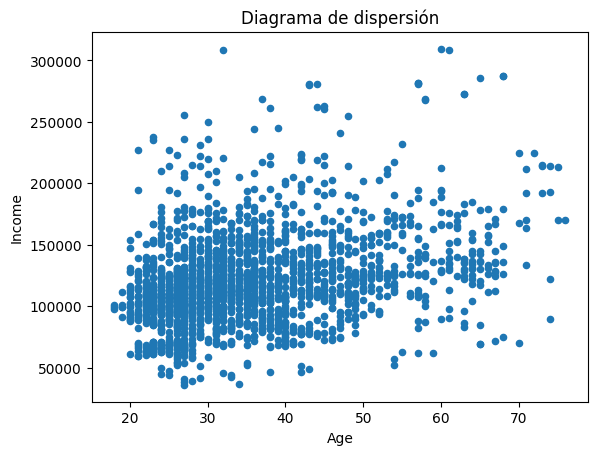

In [5]:
datos.plot(kind="scatter", x = "Age", y = "Income", title = "Diagrama de dispersión")

¿Se observan grupos claramente separados a simple vista en el plano edad-ingreso?

Como se observa en el gráfico anterior, no se distinguen grupos separados. Por el contrario, los datos se encuentran dispersos de manera aleatoria, sin un patrón identificable a simple vista.

### 2. Selección de características y escalado

Para construir los clusters se utilizarán únicamente:

$$
X = [\text{Age},\text{Income}]
$$

Las demás variables se reservarán para describir los segmentos una vez obtenidos.

In [6]:
#seleccionamos unicamente age e income para el clustering, el resto de las variables quedan en datos 
datos_ei = datos[["Age", "Income"]]
datos_ei.head()

,Age,Income
0,67,124670
1,22,150773
2,49,89210
3,45,171565
4,53,149031


Age e Income estan en escalas muy distintas (años y dolares), si lo usamos sin escalar el clustering se va a ver afectado por la escala de las variables, va a dominar las variables con mayor escala (income), por lo que es necesario escalar (estandariazamos con StandardScaler)

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(datos_ei)

#verificamos que el escalado se haya realizado correctamente, la media debe ser 0 y la desviacion estandar 1
print("Media de las variables escaladas: ", np.round(X_scaled.mean(axis=0),4))
print("Desviacion estandar de las variables escaladas: ", np.round(X_scaled.std(axis=0),4))

Media de las variables escaladas:  [0. 0.]
Desviacion estandar de las variables escaladas:  [1. 1.]


TODO EL CLUSTERING SE HACE SOBRE X_SCALED, NO SOBRE DATOS_EI NI SOBRE DATOS

### 3. Selección del número de clusters con K-Means

No se conoce de antemano cuántos grupos existen en los datos.

Ajustamos k-means para k entre 1 y 10 sobre los datos ya escalados, y guardamos la inercia de cada uno. Además guardamos los modelos en una lista para poder usarlos despues en la silueta y los diagramas de silueta.

In [8]:
rango_k = range(1, 11)
modelos_kmeans = []
inercia = []

for k in rango_k:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    modelo.fit(X_scaled)
    modelos_kmeans.append(modelo)
    inercia.append(modelo.inertia_) #inercia = wcss del modelo ya ajustado

print("Inercia por cada k (del 1 al 10): ")
for k, i in zip(rango_k, inercia):
    print(f"k={k}: WCSS={i:.2f}")


Inercia por cada k (del 1 al 10): 
k=1: WCSS=4000.00
k=2: WCSS=2260.20
k=3: WCSS=1647.55
k=4: WCSS=1281.14
k=5: WCSS=1024.24
k=6: WCSS=865.91
k=7: WCSS=751.31
k=8: WCSS=665.03
k=9: WCSS=582.93
k=10: WCSS=511.23


Calculamos el coeficiente de silueta promedio para $K \geq 2$.

In [9]:
silueta_promedio = [
    silhouette_score(X_scaled, modelo.labels_) for modelo in modelos_kmeans[1:] # usamos modelos_kmeans[1:] para k>=2 (indice 0 es k=1) 
]
print("Coeficiente de silueta promedio por cada k (del 2 al 10): ")
for k, s in zip(rango_k[1:], silueta_promedio):
    print(f"k={k}: silueta={s:.4f}")

Coeficiente de silueta promedio por cada k (del 2 al 10): 
k=2: silueta=0.4424
k=3: silueta=0.4394
k=4: silueta=0.3503
k=5: silueta=0.3648
k=6: silueta=0.3555
k=7: silueta=0.3556
k=8: silueta=0.3561
k=9: silueta=0.3617
k=10: silueta=0.3674


Representamos:
   - WCSS en función de $K$.
   - coeficiente de silueta promedio en función de $K$.

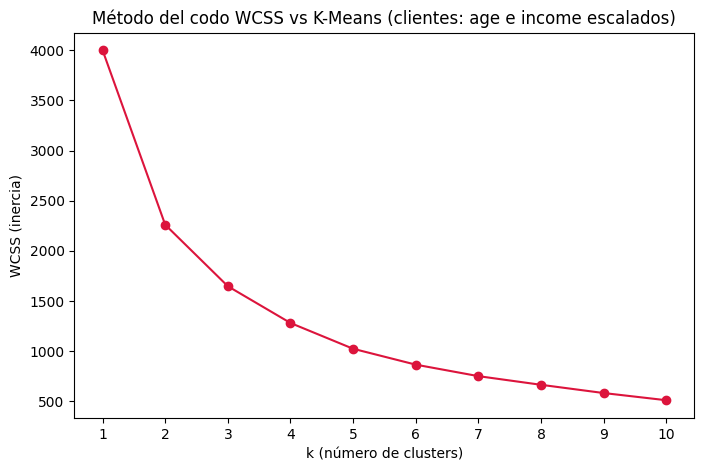

In [10]:
# Grafico de WCSS en función de k para el método del codo
plt.figure(figsize=(8, 5))
plt.plot(list(rango_k), inercia, marker="o", color="crimson")
plt.title("Método del codo WCSS vs K-Means (clientes: age e income escalados)")
plt.xlabel("k (número de clusters)"); plt.ylabel("WCSS (inercia)")
plt.xticks(list(rango_k))
plt.show()

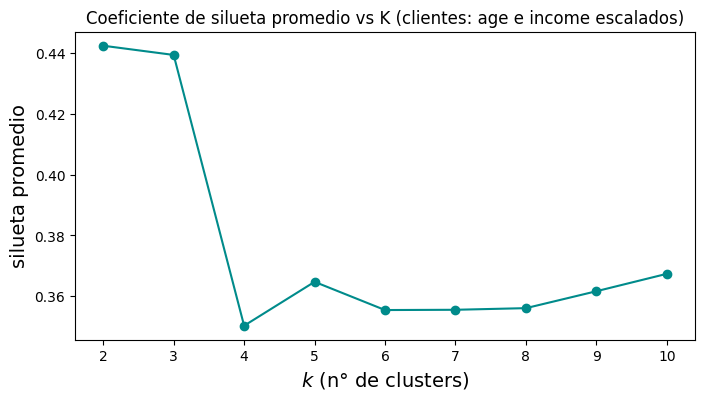

In [11]:
# Grafico de los coeficientes de silueta para cada valor de k
plt.figure(figsize=(8, 4))
plt.plot(list(range(2, 11)), silueta_promedio,color="darkcyan", marker="o") 
plt.title("Coeficiente de silueta promedio vs K (clientes: age e income escalados)")
plt.xlabel("$k$ (n° de clusters)", fontsize=14)
plt.ylabel("silueta promedio", fontsize=14)
plt.xticks(list(range(2, 11)))
plt.show()

**Identificación los valores de $K$ que considera más razonables**

Los valores más razonables son **k=2 y k=3**. El método del codo muestra una caída pronunciada de la incercia entre k=1 y k=3, y a partir de ahí la reducción se vuelve mucho más gradual. El coeficiente de silueta promedio confirma esto: k=2 (0.44) y k=3 (0.44) son claramente los más altos, muy por encima del resto (que estan entre 0.35 y 0.37) 

### 4. Análisis de los diagramas de silueta

Construimos diagramas de silueta para $K=2$, $K=3$, $K=4$ y $k=5$, para evaluar cómo se comportan las observaciones dentro de cada cluster

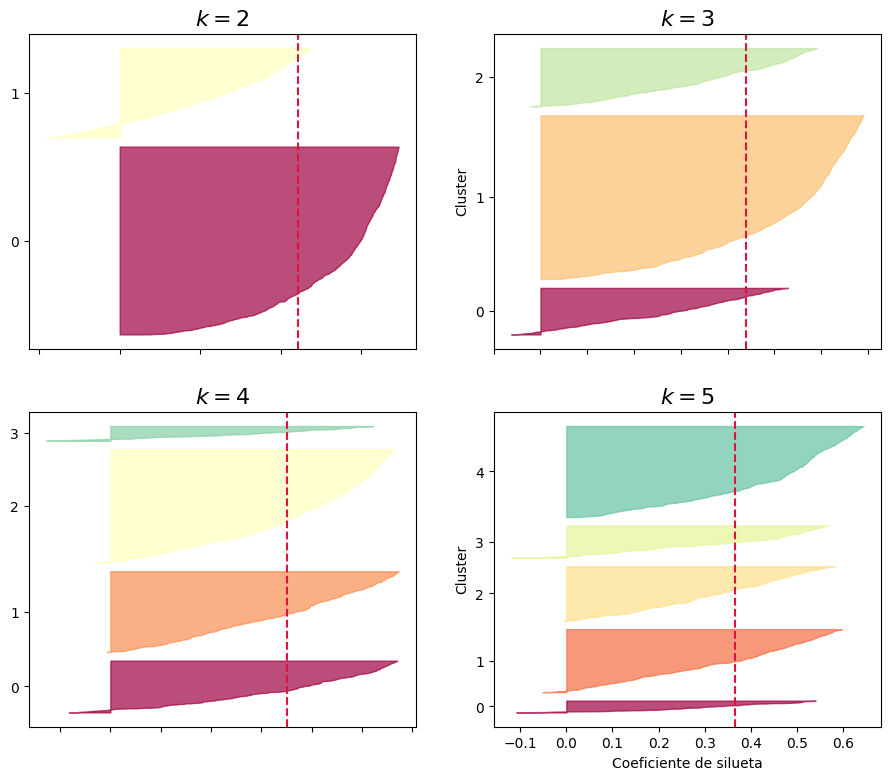

In [12]:
plt.figure(figsize=(11, 9))

for k in (2, 3, 4, 5):
    plt.subplot(2, 2, k - 1)

    y_pred = modelos_kmeans[k - 1].labels_ #etiquetas de cada instancia de X
    silhouette_coefficients = silhouette_samples(X_scaled, y_pred) #coeficientes para cada una de las instancias en X

    padding = len(X_scaled) // 30

    pos = padding
    ticks = []
    #Grafico los coeficientes de silueta por cada cluster
    for i in range(k): #i = 0,1,2..
        coeffs = silhouette_coefficients[y_pred == i] #coeficientes correspondientes a un cluster específico
        coeffs.sort()

        color = mpl.cm.Spectral(i / k) #colormap
        plt.fill_betweenx(y = np.arange(pos, pos + len(coeffs)), x1=0, x2=coeffs, facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        # plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Coeficiente de silueta")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silueta_promedio[k - 2], color="crimson", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

**Interpretacion de los diagramas de silueta** de acuerdo a los criterios vistos

Si bien k=2 y k=3 tienen prácticamente la misma silueta promedio, los diagramas muestran diferencias importantes. En k=2 la partición queda muy desbalanaceada, uno de los clusters concentra la gran mayoría de los clientes y el otro es chico. En k=3 los tres clusters quedan más equilibrados en tamaño **(a excepcion del naranja que es mas grande)** y casi todos los puntos superan el promedio general, con solo una pequeña porción de un cluster levemente por debajo de 0. Por eso, **k=3 es el valor más razonable**, ya que pocas franjas estan por debajo del cero y no hay clusters angostos.

### 5. Segmentación final con K-Means

Ajustamos el modelo K-Means utilizando el valor de K seleccionado.

Obtenemos la etiqueta asignada a cada cliente, para eso usamos el k elegido antes (k=3) y reentrenamos el modelo final sobre x_scaled. Además, calculamos los centroides.

In [13]:
k_elegido = 3
modelo_final = KMeans(n_clusters=k_elegido, n_init=10, random_state=RANDOM_STATE)
etiquetas_finales = modelo_final.fit_predict(X_scaled) #etiquetas de cada instancia de X

#guardamos las etiquetas finales en el dataframe original 
datos["Cluster"] = etiquetas_finales

# Los centroides que calcula el kmeans estan escalados, para poder tenerlos en dolares y años que es lo original 
# tenemos que desecalar los datos (lo mismo que hicimos al principio en la seccion 2)

centroides_esc_original = scaler.inverse_transform(modelo_final.cluster_centers_)

print("Centroides de los clusters en la escala original de las variables (age, income):")
for i, c in enumerate(centroides_esc_original):
    print(f"Cluster {i}: Age={c[0]:.2f} años, Income=${c[1]:.2f}")


Centroides de los clusters en la escala original de las variables (age, income):
Cluster 0: Age=35.89 años, Income=$175604.58
Cluster 1: Age=29.71 años, Income=$101742.81
Cluster 2: Age=53.28 años, Income=$131152.44


**Graficación** de los clusters con las variables originales (age, income) y los centroides de cada cluster

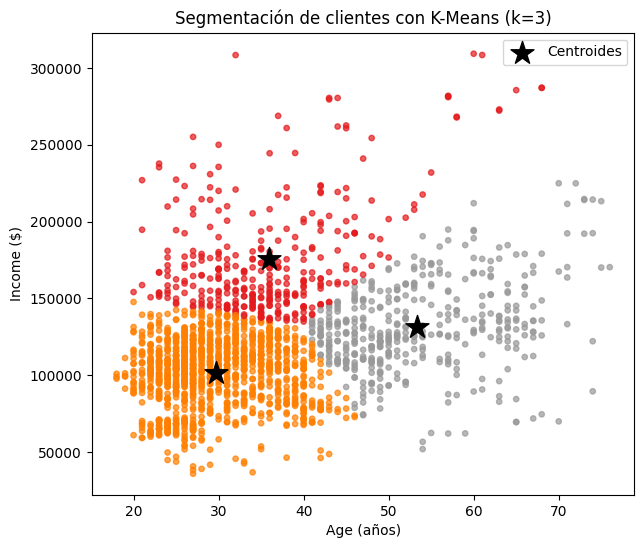

In [14]:
plt.figure(figsize=(7, 6))
plt.scatter(datos_ei["Age"], datos_ei["Income"], c=etiquetas_finales, cmap="Set1", s=15, alpha=0.7)
plt.scatter(centroides_esc_original[:, 0], centroides_esc_original[:, 1], c="black", marker="*", s=300, label="Centroides")
plt.title("Segmentación de clientes con K-Means (k=3)")
plt.xlabel("Age (años)"); plt.ylabel("Income ($)")
plt.legend()
plt.show()

**Interpretación de los grupos**

El cluster 0 agrupa clientes relativamente jóvenes (aprox. 36 años) con ingresos altos (aprox. $176.000), el segmento con mayor poder adquisitivo. El cluster 1 reúne a los clientes más jovenes (aprox. 30 años) con ingresos más bajos (aporx. $102.000), posiblemente se encuentran en etapas más tempranas de su carrera laboral. Por último, el cluster 2 corresponde a clientes de mayor edad (aprox. 53 años) con ingresos intermedios (aprox. $153.000). Es importante aclarar, que la numeración de los clusters es arbitraria, por lo tanto no implica un orden de importancia entre los grupos.

### 6. Caracterización de los segmentos

Agregamos las etiquetas de K-Means al conjunto de datos original y describimos cada cluster utilizando las características disponibles.

Para cada grupo analizamos:

- cantidad de clientes;
- edad media y mediana;
- ingreso medio y mediano;
- distribución por género;
- estado civil;
- nivel educativo;
- ocupación;
- tamaño de la ciudad de residencia.

A partir de estos resultados, elabore una descripción breve de cada segmento. Puede utilizar herramientas de `pandas` para esta tarea.

In [15]:
#mapeamos los codigos numericos a etiquetas legibles usando los datos del principio
#esto no cambia el dataset original es solo para que la tabla sea mas facil de leer
mapeo_sexo = {0: "masculino", 1: "femenino"}
mapeo_marital = {0: "soltero/a", 1: "no soltero (divorciado/separado/casado/viudo)"}
mapeo_education = {0: "otro/desconocido", 1: "secundario", 2: "universitario", 3: "posgrado"}
mapeo_ocupacion = {0: "desempleado/no calificado", 1: "empleado calificado", 2: "gerencial/autonomo/alta calificacion"}
mapeo_asentamiento = {0: "ciudad pequeña", 1: "ciudad mediana", 2: "gran ciudad"}

datos_legibles = datos.copy()
datos_legibles["Sexo"] = datos_legibles["Sex"].map(mapeo_sexo)
datos_legibles["Estado Civil"] = datos_legibles["Marital status"].map(mapeo_marital)
datos_legibles["Nivel de Educación"] = datos_legibles["Education"].map(mapeo_education)
datos_legibles["Ocupación"] = datos_legibles["Occupation"].map(mapeo_ocupacion)
datos_legibles["Asentamiento"] = datos_legibles["Settlement size"].map(mapeo_asentamiento)
datos_legibles["Cluster"] = etiquetas_finales

In [16]:
print("Cantidad de clientes en cada cluster:")
print(datos["Cluster"].value_counts().sort_index())

Cantidad de clientes en cada cluster:
Cluster
0     347
1    1218
2     435
Name: count, dtype: int64


In [17]:
print("Edad e ingreso: media y mediana")
resumen_numerico = datos_legibles.groupby("Cluster").agg(
    edad_media=("Age", "mean"),
    edad_mediana=("Age", "median"),
    ingreso_medio=("Income", "mean"),
    ingreso_mediano=("Income", "median"),
).round(1)

resumen_numerico

Edad e ingreso: media y mediana


,edad_media,edad_mediana,ingreso_medio,ingreso_mediano
Cluster,,,,
0,35.9,35.0,175604.6,162827.0
1,29.7,29.0,101742.8,104405.5
2,53.3,51.0,131152.4,127825.0


In [18]:
print("Distribuciones por cluster:")

def distribucion_categorica(col):
    tabla = datos_legibles.groupby("Cluster")[col].value_counts(normalize=True) * 100 # calculamos el porcentaje de cliente en cada categoria
    tabla = tabla.round(1)
    tabla = tabla.unstack() #pasamos a tabla (dataframe) para que sea mas facil de leer
    return tabla

print("Distribución de sexo: ")
print(distribucion_categorica("Sexo"))
print("Distribución de estado civil: ")
print(distribucion_categorica("Estado Civil"))
print("Distribución de nivel de educación: ")
print(distribucion_categorica("Nivel de Educación"))


Distribuciones por cluster:
Distribución de sexo: 
Sexo     femenino  masculino
Cluster                     
0            25.4       74.6
1            54.9       45.1
2            36.1       63.9
Distribución de estado civil: 
Estado Civil  no soltero (divorciado/separado/casado/viudo)  soltero/a
Cluster                                                               
0                                                      39.5       60.5
1                                                      56.7       43.3
2                                                      37.9       62.1
Distribución de nivel de educación: 
Nivel de Educación  otro/desconocido  posgrado  secundario  universitario
Cluster                                                                  
0                               17.6       1.7        66.9           13.8
1                               18.6       0.4        79.6            1.5
2                                NaN       5.7        42.5           51.7


In [19]:
print("Distribución de ocupación: ")
print(distribucion_categorica("Ocupación"))
print("Distribución de asentamiento: ") 
print(distribucion_categorica("Asentamiento"))

Distribución de ocupación: 
Ocupación  desempleado/no calificado  empleado calificado  \
Cluster                                                     
0                                3.7                 44.4   
1                               40.1                 57.6   
2                               30.1                 59.3   

Ocupación  gerencial/autonomo/alta calificacion  
Cluster                                          
0                                          51.9  
1                                           2.3  
2                                          10.6  
Distribución de asentamiento: 
Asentamiento  ciudad mediana  ciudad pequeña  gran ciudad
Cluster                                                  
0                       41.2            12.1         46.7
1                       21.1            62.8         16.1
2                       33.1            41.8         25.1


In [20]:
tamaño_ciudad = datos_legibles.groupby("Cluster")["Settlement size"].value_counts(normalize=True) * 100
tamaño_ciudad = tamaño_ciudad.round(1)
tamaño_ciudad

Cluster  Settlement size
0        2                  46.7
         1                  41.2
         0                  12.1
1        0                  62.8
         1                  21.1
         2                  16.1
2        0                  41.8
         1                  33.1
         2                  25.1
Name: proportion, dtype: float64

### 7. Agrupamiento jerárquico aglomerativo

Aplicamos agrupamiento jerárquico sobre las mismas variables estandarizadas

Primero Construimos un dendrograma utilizando distancia Euclídea y enlace completo (`complete`).

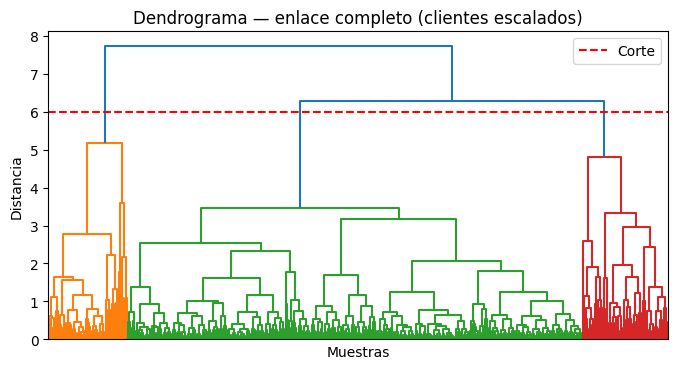

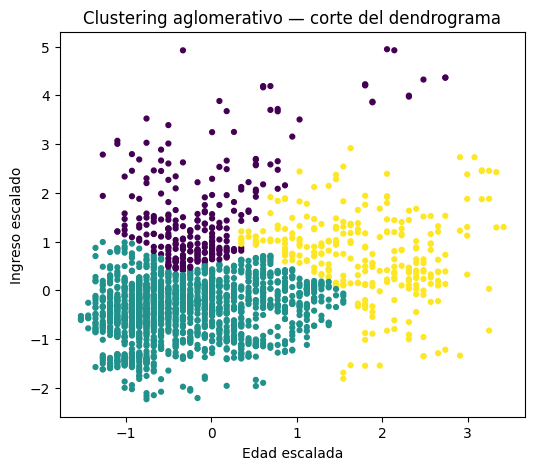

In [21]:
Z = linkage(X_scaled, method="complete", metric="euclidean") # Utilizamos la distancia euclídea y el método de enlace completo

# Dendrograma
plt.figure(figsize=(8, 4))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.axhline(y=6.0, color="red", linestyle="--", label="Corte") # hace un corte en 6 y nos permite obtener 3 clusters como en el kmeans
plt.title("Dendrograma — enlace completo (clientes escalados)")
plt.xlabel("Muestras")
plt.ylabel("Distancia")
plt.legend()
plt.show()

hier_labels = fcluster(Z, t=6.0, criterion="distance")

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=12, c=hier_labels)
plt.title("Clustering aglomerativo — corte del dendrograma")
plt.xlabel("Edad escalada")
plt.ylabel("Ingreso escalado")
plt.show()

Analisis de las últimas fusiones del árbol 

Las dos últimas fusiones del dendrograma ocurren a distancias entre 6 y 8, marcando saltos notoriamente mayores que las fusiones anteriores (que rondan 3.5 – 5). Esto sugiere que, por debajo de una altura cercana a 6, la estructura de agrupamiento es estable y separa tres grupos. Obteneiendo asi una partición con un numero de clusters igual al obtenido con k-means (k=3)

Calculamos el coeficiente de silueta para ese número de clusters y lo comparamos visualmente ambas soluciones.

In [22]:
silueta_jerarquico = silhouette_score(X_scaled, hier_labels)
print(f"Coeficiente de silueta promedio para clustering jerárquico: {silueta_jerarquico:.4f}")
silueta_kmeans_final = silhouette_score(X_scaled, etiquetas_finales)
print(f"Coeficiente de silueta promedio para K-Means: {silueta_kmeans_final:.4f}")

Coeficiente de silueta promedio para clustering jerárquico: 0.4021
Coeficiente de silueta promedio para K-Means: 0.4394


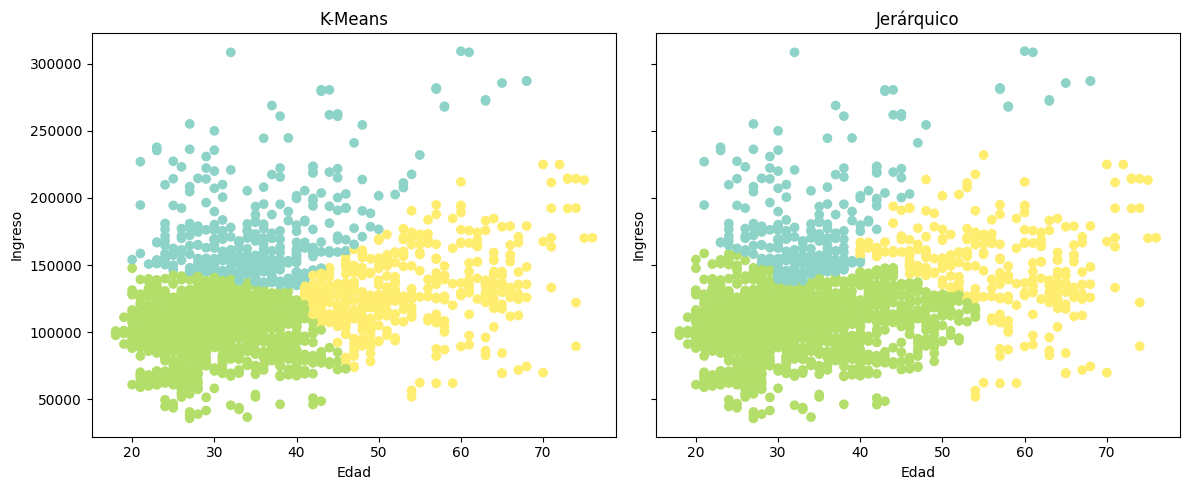

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# K-Means
axes[0].scatter(datos["Age"], datos["Income"], c=etiquetas_finales, cmap="Set3")
axes[0].set_title("K-Means")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Ingreso")

# Jerárquico
axes[1].scatter(datos["Age"], datos["Income"], c=hier_labels, cmap = "Set3")
axes[1].set_title("Jerárquico")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Ingreso")

plt.tight_layout()
plt.show()

### 8. Análisis final

A partir de todo el procedimiento, responda:

1. ¿Qué valor de $K$ considera más adecuado para K-Means? Fundamente utilizando WCSS, silueta e interpretación de los clusters.

    Según lo visto anteriormente el valor más adecuado es $K$ = 3, ya que el método del codo muestra una caída pronunciada del WCSS entre 1 y 3, y a partir de ahi se vuelve más gradual, lo que indica que agregar mas cluster produce mejoras cada vez menores. El coeficiente de silueta promedio confirma esta elección debido a que k=2 y k=3 obtienen los valores más altos (~0.44), por encima del resto. Sin embargo, al observar los diagramas de silueta, k=2 genera un partición desbalanceada mientras que k =3 presenta grupos mas equilibrados en tamaño, donde la mayoria de las observaciones superan la silueta promedio general.

2. ¿Qué perfiles de clientes identifica?

    Los perfiles que se lograron identificar son lo siguiente:
    - Cluster 0: 
        Jóvenes con edad promedio de 36 años e ingreso promedio de $176.000, el segmento con mayor poder adquisitivo. Predomina el género masculino (74.6%) y el estado civil soltero (60%), con nivel educativo secundario como el más frecuente. Además, muestran una tendencia a residir en ciudades grandes o medianas.
    - Cluster 1: 
        Jóvenes con edad promedio de 30 años e ingreso promedio de $102.000, el segmento con menor poder adquisitivo. Predomina el género femenino (54.9%) y el estado civil casado/a (56.7%), con nivel educativo secundario como el más frecuente (79.6%). Además, muestran una fuerte tendencia a residir en ciudades pequeñas (62.8%).
    - Cluster 2: 
        Adultos con edad promedio de 53 años e ingreso promedio de $132.000, un segmento de ingresos intermedios. Predomina el género masculino (63.9%) y el estado civil soltero/a (62.1%), con una distribución pareja entre nivel universitario (51.7%) y secundario (42.5%) en cuanto a educación. Además, tienen un menor presencia en grandes ciudades (25.1%).
    
3. ¿Qué diferencias encuentra entre K-Means y el agrupamiento jerárquico?

    Ambos métodos coinciden en identificar 3 clusters como una partición razonable, y las formas generales de los grupos son similares. Sin embargo, difieren en el criterio, debido a que K-Means busca minimizar la distancia de cada punto a un centroide, generando clusters de forma más esférica y de tamaños relativamente balanceados; y el agrupamiento jerárquico con enlace completo, fusiona observaciones según la distancia máxima entre puntos de distintos clusters, lo que puede generar límites algo distintos entre grupos, especialmente en las zonas de solapamiento entre edad e ingreso. Al comparar los gráficos, se observa que la asignación de algunos clientes ubicados en los bordes entre grupos cambia según el método utilizado.

4. ¿Qué limitación introduce construir los clusters únicamente con `Age` e `Income`?

    Al construir los clusters únicamente con `Age` e `Income` se generan limitaciones ya que el modelo ignora el resto de la información adicional. Haciendo que dos clientes con edad e ingresos similares terminen en el mismo cluster, aun cuando sus perfiles son muy distintos. Por lo que no necesariamente refleja los disntintos comportamientamientos de compras.
    
5. ¿Por qué no sería correcto afirmar que los clusters encontrados son las únicas categorías posibles de clientes?

   No, ya que el clustering es un método no supervisado cuyo resultado depende de decisiones metodológicas, como la elección de variables, el escalado, la métrica de distancia, el algoritmo utilizado y el valor de K seleccionado. Si se modificara alguna de estas decisiones, se obtendrían agrupamientos distintos, pero igualmente válidos desde el punto de vista estadístico.